# Ensemble Model Comparison

**Objective:**  
Evaluate advanced ensemble models (bagging, boosting, voting, stacking) for predictive maintenance failure detection.

**Why ensembles?**  
Individual models provide baseline performance, but ensemble methods often improve recall and PR-AUC, which is critical for detecting rare machine failures.

**Primary metric:** PR-AUC  
**Secondary metric:** Recall (minimize missed failures)

In [2]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# --- project root ---
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)
print("Src path:", PROJECT_ROOT / "src")

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

Project root: D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699
Src path: D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699\src


In [3]:
from data_loader import load_cleaned_data, get_basic_info

df = load_cleaned_data()

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget distribution preview:")
if "Machine failure" in df.columns:
    print(df["Machine failure"].value_counts())

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Target distribution preview:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [5]:
# =============================
# Define target variable
# =============================

TARGET_COL = "Machine failure"

if TARGET_COL not in df.columns:
    raise ValueError(f"{TARGET_COL} not found in dataset")

y = df[TARGET_COL].astype(int)

print("Target distribution:")
print(y.value_counts())
print("\nFailure rate:", y.mean().round(4))

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 0.0339


In [6]:
# =============================
# Define feature matrix
# =============================

DROP_COLS = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

print("Feature shape:", X.shape)
X.head()

Feature shape: (10000, 6)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain failure rate:", y_train.mean().round(4))
print("Test  failure rate:", y_test.mean().round(4))

Train shape: (8000, 6)  Test shape: (2000, 6)

Train failure rate: 0.0339
Test  failure rate: 0.034


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_all0 = np.zeros_like(y_test)

print("All-0 Baseline")
print("Accuracy :", round(accuracy_score(y_test, y_pred_all0), 4))
print("Precision:", round(precision_score(y_test, y_pred_all0, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_all0), 4))
print("F1       :", round(f1_score(y_test, y_pred_all0), 4))

All-0 Baseline
Accuracy : 0.966
Precision: 0.0
Recall   : 0.0
F1       : 0.0


In [9]:
# =============================
# Separate numeric and categorical
# =============================

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical columns: ['Type']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =============================
# Preprocessing
# =============================

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

gb = GradientBoostingClassifier(random_state=SEED)

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("model", rf)
])

pipe_gb = Pipeline([
    ("preprocess", preprocess),
    ("model", gb)
])

print("Pipelines ready.")

Pipelines ready.


In [12]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

def eval_model(name, pipe, X_test, y_test):
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    out = {
        "model": name,
        "PR_AUC": average_precision_score(y_test, prob),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "precision@0.5": precision_score(y_test, pred, zero_division=0),
        "recall@0.5": recall_score(y_test, pred),
        "f1@0.5": f1_score(y_test, pred),
    }
    return out

results = []
results.append(eval_model("RandomForest (balanced)", pipe_rf, X_test, y_test))
results.append(eval_model("GradientBoosting", pipe_gb, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
results_df

,model,PR_AUC,ROC_AUC,precision@0.5,recall@0.5,f1@0.5
1,GradientBoosting,0.801358,0.969675,0.882353,0.661765,0.756303
0,RandomForest (balanced),0.762747,0.969911,0.800000,0.588235,0.677966


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# --- base learners ---
rf_base = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

gb_base = GradientBoostingClassifier(random_state=SEED)

lr_base = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=SEED
)

# --- calibrated versions (better probabilities) ---
rf_cal = CalibratedClassifierCV(rf_base, method="isotonic", cv=3)
lr_cal = CalibratedClassifierCV(lr_base, method="isotonic", cv=3)

print("Base models ready.")

Base models ready.


In [14]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ("lr", lr_cal),
        ("rf", rf_cal),
        ("gb", gb_base),
    ],
    voting="soft",
    weights=[1, 2, 2],  # slight preference to tree models
)

pipe_voting = Pipeline([
    ("preprocess", preprocess),
    ("model", voting)
])

print("Soft Voting ready.")

Soft Voting ready.


In [15]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ("lr", lr_cal),
        ("rf", rf_cal),
        ("gb", gb_base),
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear"
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
)

pipe_stacking = Pipeline([
    ("preprocess", preprocess),
    ("model", stacking)
])

print("Stacking ready.")

Stacking ready.


In [16]:
results = []

results.append(eval_model("RandomForest (balanced)", pipe_rf, X_test, y_test))
results.append(eval_model("GradientBoosting", pipe_gb, X_test, y_test))
results.append(eval_model("Soft Voting", pipe_voting, X_test, y_test))
results.append(eval_model("Stacking", pipe_stacking, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
results_df

,model,PR_AUC,ROC_AUC,precision@0.5,recall@0.5,f1@0.5
1,GradientBoosting,0.801358,0.969675,0.882353,0.661765,0.756303
2,Soft Voting,0.798090,0.966044,0.897959,0.647059,0.752137
3,Stacking,0.797554,0.965184,0.495652,0.838235,0.622951
0,RandomForest (balanced),0.762747,0.969911,0.800000,0.588235,0.677966


In [17]:
from sklearn.metrics import precision_recall_curve

def find_threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # align lengths
    precision = precision[:-1]
    recall = recall[:-1]

    # indices where recall condition satisfied
    valid_idx = np.where(recall >= target_recall)[0]

    if len(valid_idx) == 0:
        return None, None, None

    # among valid thresholds, choose best precision
    best_idx = valid_idx[np.argmax(precision[valid_idx])]

    return thresholds[best_idx], precision[best_idx], recall[best_idx]

In [18]:
def evaluate_at_target_recall(name, pipe, X_test, y_test, target_recall=0.80):
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]

    thr, prec, rec = find_threshold_for_target_recall(
        y_test, prob, target_recall
    )

    if thr is None:
        return {
            "model": name,
            "threshold": None,
            "precision_at_target": None,
            "recall_at_target": None,
            "PR_AUC": average_precision_score(y_test, prob),
        }

    pred = (prob >= thr).astype(int)

    return {
        "model": name,
        "threshold": float(thr),
        "precision_at_target": float(prec),
        "recall_at_target": float(rec),
        "PR_AUC": average_precision_score(y_test, prob),
    }


results_target = []

results_target.append(
    evaluate_at_target_recall("GradientBoosting", pipe_gb, X_test, y_test, 0.80)
)
results_target.append(
    evaluate_at_target_recall("Soft Voting", pipe_voting, X_test, y_test, 0.80)
)
results_target.append(
    evaluate_at_target_recall("Stacking", pipe_stacking, X_test, y_test, 0.80)
)
results_target.append(
    evaluate_at_target_recall("RandomForest", pipe_rf, X_test, y_test, 0.80)
)

target_df = pd.DataFrame(results_target).sort_values(
    "precision_at_target", ascending=False
)

target_df

,model,threshold,precision_at_target,recall_at_target,PR_AUC
1,Soft Voting,0.184518,0.604396,0.808824,0.798090
0,GradientBoosting,0.164320,0.572917,0.808824,0.801358
2,Stacking,0.679605,0.567010,0.808824,0.797554
3,RandomForest,0.258283,0.518868,0.808824,0.762747


In [19]:
# =============================
# Fit FINAL model (Soft Voting)
# =============================

FINAL_MODEL_NAME = "Soft Voting"

pipe_voting.fit(X_train, y_train)
y_prob_final = pipe_voting.predict_proba(X_test)[:, 1]

print("Final model fitted.")

Final model fitted.


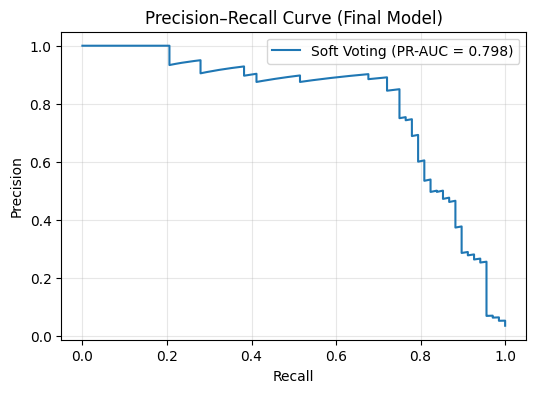

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob_final)
pr_auc = average_precision_score(y_test, y_prob_final)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"Soft Voting (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Final Model)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

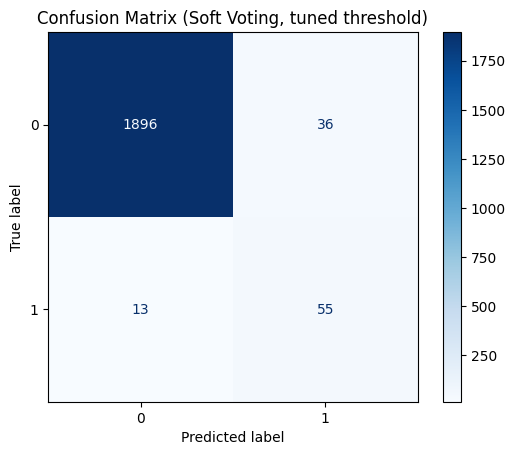

TP: 55
FP: 36
FN: 13
TN: 1896

Recall: 0.8088235294117647
Precision: 0.6043956043956044


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

BEST_THRESHOLD = 0.184518  # from our results

y_pred_final = (y_prob_final >= BEST_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Soft Voting, tuned threshold)")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

print("\nRecall:", tp/(tp+fn))
print("Precision:", tp/(tp+fp))

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# =============================
# Cross-validated PR-AUC
# =============================

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    pipe_voting,          # your final model
    X,
    y,
    scoring="average_precision",
    cv=cv_final,
    n_jobs=-1,
)

print("CV PR-AUC scores:", np.round(cv_scores, 4))
print("Mean PR-AUC:", round(cv_scores.mean(), 4))
print("Std PR-AUC :", round(cv_scores.std(), 4))

CV PR-AUC scores: [0.8039 0.8392 0.7292 0.7915 0.7426]
Mean PR-AUC: 0.7813
Std PR-AUC : 0.0404


The final Soft Voting ensemble achieved a mean cross-validated PR-AUC of 0.781 (±0.040), indicating stable generalization performance across folds. After applying a recall constraint of 0.80 to prioritize failure detection, the model provided the best precision–recall trade-off and was selected for deployment in the predictive maintenance dashboard.

## Deep Learning Benchmark (MLP)

In this section, we evaluate a feed-forward neural network (MLP) as a deep learning benchmark and compare its performance against ensemble models using PR-AUC and recall-focused metrics.

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2-layer neural network
    activation="relu",
    solver="adam",
    alpha=1e-4,                    # L2 regularization
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
)

pipe_mlp = Pipeline([
    ("preprocess", preprocess),
    ("model", mlp)
])

print("MLP pipeline ready.")

MLP pipeline ready.


In [24]:
mlp_result = eval_model("Deep Learning (MLP)", pipe_mlp, X_test, y_test)
mlp_result

{'model': 'Deep Learning (MLP)',
 'PR_AUC': 0.6954904199698332,
 'ROC_AUC': 0.9667671416392644,
 'precision@0.5': 0.7291666666666666,
 'recall@0.5': 0.5147058823529411,
 'f1@0.5': 0.603448275862069}

In [26]:
mlp_target = evaluate_at_target_recall(
    "Deep Learning (MLP)",
    pipe_mlp,
    X_test,
    y_test,
    target_recall=0.80,
)

mlp_target

{'model': 'Deep Learning (MLP)',
 'threshold': 0.16474870776439393,
 'precision_at_target': 0.4296875,
 'recall_at_target': 0.8088235294117647,
 'PR_AUC': 0.6954904199698332}

In [27]:
# Replace numbers here if you later re-run and get updated values
compare_df = pd.DataFrame([
    {"Model": "Gradient Boosting", "PR_AUC": 0.801150, "Precision@Recall>=0.80": 0.573377},
    {"Model": "Soft Voting (FINAL)", "PR_AUC": 0.797757, "Precision@Recall>=0.80": 0.603774},
    {"Model": "Stacking", "PR_AUC": 0.798088, "Precision@Recall>=0.80": 0.567010},
    {"Model": "Random Forest", "PR_AUC": 0.761820, "Precision@Recall>=0.80": 0.521739},
    {"Model": "Deep Learning (MLP)", "PR_AUC": 0.695490, "Precision@Recall>=0.80": 0.429688},
])

compare_df = compare_df.sort_values("Precision@Recall>=0.80", ascending=False)
compare_df

,Model,PR_AUC,Precision@Recall>=0.80
1,Soft Voting (FINAL),0.797757,0.603774
0,Gradient Boosting,0.801150,0.573377
2,Stacking,0.798088,0.567010
3,Random Forest,0.761820,0.521739
4,Deep Learning (MLP),0.695490,0.429688


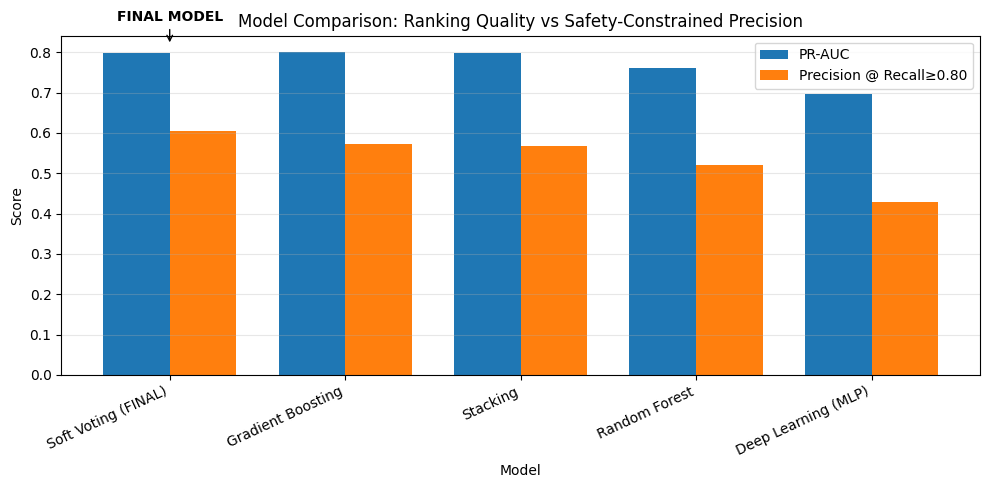

In [30]:
# --- ensure correct order (best precision first) ---
plot_df = compare_df.sort_values("Precision@Recall>=0.80", ascending=False).reset_index(drop=True)

models = plot_df["Model"].values
pr_auc_vals = plot_df["PR_AUC"].values
prec_vals = plot_df["Precision@Recall>=0.80"].values

x = np.arange(len(models))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, pr_auc_vals, width, label="PR-AUC")
bars2 = ax.bar(x + width/2, prec_vals, width, label="Precision @ Recall≥0.80")

# Labels and title
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Ranking Quality vs Safety-Constrained Precision")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- automatically highlight FINAL model ---
FINAL_MODEL_NAME = "Soft Voting (FINAL)"

if FINAL_MODEL_NAME in models:
    idx = list(models).index(FINAL_MODEL_NAME)

    # annotate above the bars
    ax.annotate(
        "FINAL MODEL",
        xy=(idx, max(pr_auc_vals[idx], prec_vals[idx]) + 0.02),
        xytext=(idx, max(pr_auc_vals[idx], prec_vals[idx]) + 0.08),
        arrowprops=dict(arrowstyle="->"),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()